# Defaulter Predictor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
days_left = 10
required_attendance = 60
attendance_per_lec = 1.25
lec_per_week = 4

theory = ['DBMS', 'TOC', 'SPOS', 'CNS', 'IOT']
practical = ['DBMSL', 'CNSL', 'LPI']

print("=" * 70)
print("STUDENT DEFAULTER PREDICTION SYSTEM")
print("=" * 70)
print(f"\n📅 Days remaining: {days_left} days")
print(f"🎯 Required attendance: {required_attendance}%")
print(f"📈 Attendance per lecture: ~{attendance_per_lec}%")

STUDENT DEFAULTER PREDICTION SYSTEM

📅 Days remaining: 10 days
🎯 Required attendance: 60%
📈 Attendance per lecture: ~1.25%


In [3]:
# loading data

df = pd.read_csv('attendance.csv')
print(f"\nTotal students: {len(df)}")
print(f"Current average attendance: {df['Average'].mean():.2f}%")


Total students: 77
Current average attendance: 40.99%


In [4]:
week_left = days_left / 7

total_theory_left = len(theory) * 3 * week_left
total_practical_left = len(practical) * 1 * week_left
total_lec_left = total_theory_left + total_practical_left
print(f"Estimated total lectures in {days_left} days: {total_lec_left:.0f}")

max_attendance_gain = total_lec_left * attendance_per_lec
print(f"Maximum possible attendance gain: {max_attendance_gain:.2f}%")

Estimated total lectures in 10 days: 26
Maximum possible attendance gain: 32.14%


In [5]:
# attendance prediction

# best case 
df['Current_Attendance'] = df['Average']
df['Best_Case_Attendance'] = df['Current_Attendance'] + max_attendance_gain
df['Best_Case_Attendance'] = df['Best_Case_Attendance'].clip(upper=100)

# worst case
df['Worst_Case_Attendance'] = df['Current_Attendance']

realistic_gain = max_attendance_gain * 0.8
df['Realistic_Attendance'] = df['Current_Attendance'] + realistic_gain
df['Realistic_Attendance'] = df['Realistic_Attendance'].clip(upper=100)

In [6]:
# categorization

def categorize_students(row):
    current = row['Current_Attendance']
    best_case = row['Best_Case_Attendance']
    realistic = row['Realistic_Attendance']

    if current > required_attendance:
        return "Not in defaulter"
    elif best_case < required_attendance:
        return "Certain defaulter"
    elif realistic >= required_attendance:
        return "At risk"
    else:
        return "Defaulter"
    
df['Status'] = df.apply(categorize_students, axis=1)
df['Attendance_Gap'] = required_attendance - df['Current_Attendance']

In [7]:
safe_students = df[df['Current_Attendance'] >= required_attendance].copy()

# Certain defaulters (impossible to reach 60% even with 100% attendance)
certain_defaulters = df[df['Best_Case_Attendance'] < required_attendance].copy()

# At risk but can be saved
at_risk = df[(df['Current_Attendance'] < required_attendance) & 
             (df['Best_Case_Attendance'] >= required_attendance) &
             (df['Realistic_Attendance'] >= required_attendance)].copy()

# Likely defaulters (need 100% attendance)
likely_defaulters = df[(df['Current_Attendance'] < required_attendance) & 
                       (df['Best_Case_Attendance'] >= required_attendance) &
                       (df['Realistic_Attendance'] < required_attendance)].copy()

In [8]:
print(f"\n✅ SAFE Students (Already ≥60%): {len(safe_students)}")
print(f"⚠️  AT RISK (Can be saved): {len(at_risk)}")
print(f"🔴 LIKELY DEFAULTERS (Need 100% attendance): {len(likely_defaulters)}")
print(f"🚨 CERTAIN DEFAULTERS (Impossible to save): {len(certain_defaulters)}")

print(f"\n{'='*70}")
print("🚨 CERTAIN DEFAULTERS - URGENT ACTION NEEDED!")
print(f"{'='*70}")
if len(certain_defaulters) > 0:
    print("\nThese students CANNOT reach 60% even if they attend all remaining lectures:\n")
    for idx, row in certain_defaulters.iterrows():
        print(f"{row['Student_Number']:3}. {row['Student_Name']:30} | "
              f"Current: {row['Current_Attendance']:5.2f}% | "
              f"Best Case: {row['Best_Case_Attendance']:5.2f}% | "
              f"Gap: {row['Attendance_Gap']:5.2f}%")
else:
    print("\n🎉 No certain defaulters! All students can still be saved!")

print(f"\n{'='*70}")
print("🔴 LIKELY DEFAULTERS - MUST ATTEND ALL LECTURES!")
print(f"{'='*70}")
if len(likely_defaulters) > 0:
    print("\nThese students must attend 100% of remaining lectures to reach 60%:\n")
    for idx, row in likely_defaulters.iterrows():
        print(f"{row['Student_Number']:3}. {row['Student_Name']:30} | "
              f"Current: {row['Current_Attendance']:5.2f}% | "
              f"Need: 100% attendance | "
              f"Gap: {row['Attendance_Gap']:5.2f}%")
else:
    print("\n✅ No likely defaulters!")

print(f"\n{'='*70}")
print("⚠️  AT RISK - SHOULD ATTEND REGULARLY")
print(f"{'='*70}")
if len(at_risk) > 0:
    print("\nThese students can reach 60% with regular attendance (80%+):\n")
    for idx, row in at_risk.iterrows():
        print(f"{row['Student_Number']:3}. {row['Student_Name']:30} | "
              f"Current: {row['Current_Attendance']:5.2f}% | "
              f"Realistic: {row['Realistic_Attendance']:5.2f}% | "
              f"Gap: {row['Attendance_Gap']:5.2f}%")
else:
    print("\n✅ No students at risk!")

print(f"\n{'='*70}")
print("✅ SAFE STUDENTS")
print(f"{'='*70}")
print(f"\n{len(safe_students)} students already have ≥60% attendance")
if len(safe_students) <= 10:
    print("\nTop performers:")
    for idx, row in safe_students.nlargest(len(safe_students), 'Current_Attendance').iterrows():
       print(f"{row['Student_Number']:3}. {row['Student_Name']:30} | {row['Current_Attendance']:5.2f}%")


✅ SAFE Students (Already ≥60%): 15
⚠️  AT RISK (Can be saved): 38
🔴 LIKELY DEFAULTERS (Need 100% attendance): 4
🚨 CERTAIN DEFAULTERS (Impossible to save): 20

🚨 CERTAIN DEFAULTERS - URGENT ACTION NEEDED!

These students CANNOT reach 60% even if they attend all remaining lectures:

  2. GHULE UMESH PANDHARINATH       | Current: 26.87% | Best Case: 59.01% | Gap: 33.13%
  4. GIRI VIJAY PANDURANG           | Current: 10.45% | Best Case: 42.59% | Gap: 49.55%
  6. INGLE RAHUL VIJAY              | Current:  2.99% | Best Case: 35.13% | Gap: 57.01%
  8. JADHAV GAURAV BAPUSAHEB        | Current:  4.48% | Best Case: 36.62% | Gap: 55.52%
  9. JADHAV HARSHAL PRASHANT        | Current: 15.67% | Best Case: 47.81% | Gap: 44.33%
 19. JIROBE SARVESH SURESH          | Current: 25.37% | Best Case: 57.51% | Gap: 34.63%
 20. KADAM OMKAR UDDHAV             | Current:  5.97% | Best Case: 38.11% | Gap: 54.03%
 21. KADAM SATYAM KISHOR            | Current: 25.37% | Best Case: 57.51% | Gap: 34.63%
 23. KAKKAD H

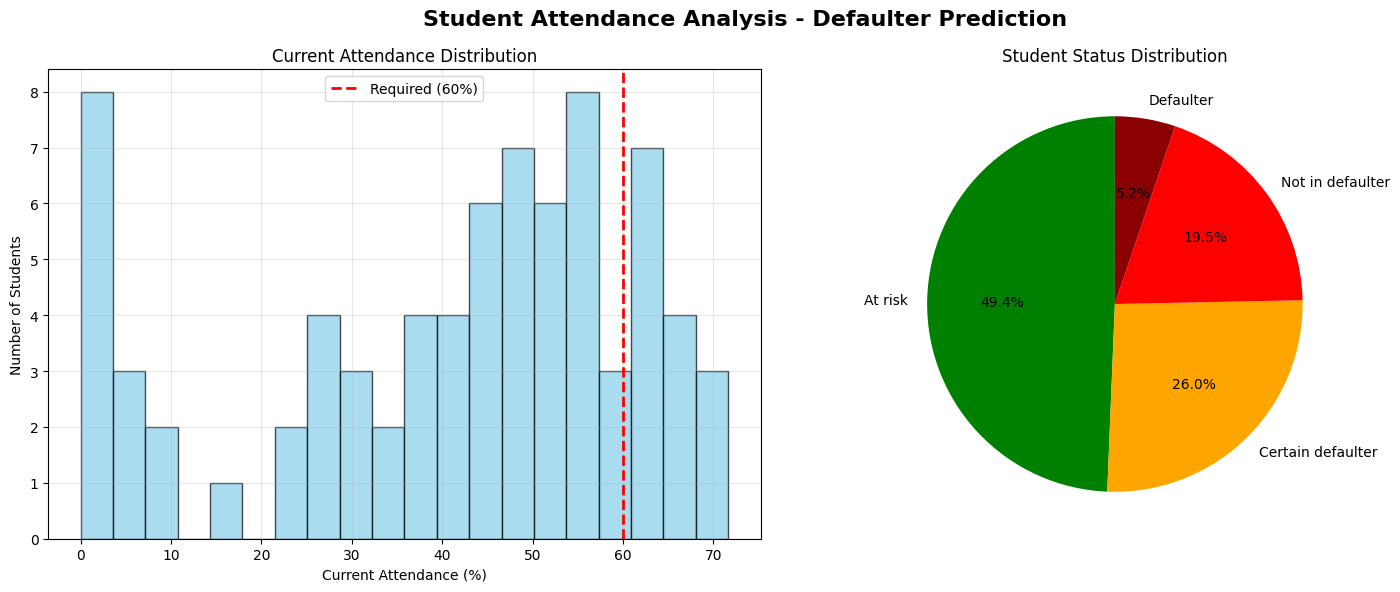

In [9]:
# visualize 

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Student Attendance Analysis - Defaulter Prediction', 
             fontsize=16, fontweight='bold')

# Plot 1: Current attendance distribution
axes[0].hist(df['Current_Attendance'], bins=20, color='skyblue', 
                edgecolor='black', alpha=0.7)
axes[0].axvline(x=required_attendance, color='red', linestyle='--', 
                   linewidth=2, label='Required (60%)')
axes[0].set_xlabel('Current Attendance (%)')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Current Attendance Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Category distribution
categories = df['Status'].value_counts()
colors = ['green', 'orange', 'red', 'darkred']
axes[1].pie(categories.values, labels=categories.index, autopct='%1.1f%%',
               colors=colors[:len(categories)], startangle=90)
axes[1].set_title('Student Status Distribution')

plt.tight_layout()
plt.show()

In [10]:
all_defaulters = pd.concat([certain_defaulters, likely_defaulters, at_risk])
all_defaulters = all_defaulters.sort_values('Current_Attendance')

print(f"\n🚨 Total Defaulters: {len(all_defaulters)} students")
print(f"   - Certain Defaulters: {len(certain_defaulters)}")
print(f"   - Likely Defaulters: {len(likely_defaulters)}")
print(f"   - At Risk: {len(at_risk)}")

print(f"\n{'='*70}")
print("ALL DEFAULTER NAMES (Sorted by Current Attendance)")
print(f"{'='*70}\n")

if len(all_defaulters) > 0:
    print(f"{'Sr.':<5} {'Roll':<5} {'Student Name':<35} {'Current':<10} {'Status':<30}")
    print("-" * 90)
    
    for i, (idx, row) in enumerate(all_defaulters.iterrows(), 1):
        status_emoji = "🚨" if row['Status'].startswith("🚨") else \
                       "🔴" if row['Status'].startswith("🔴") else "⚠️"
        
        print(f"{i:<5} {row['Student_Number']:<5} {row['Student_Name']:<35} "
              f"{row['Current_Attendance']:>6.2f}%   {status_emoji} {row['Status']}")
    
    print("\n" + "="*90)
    
    # Quick reference list - Just names
    print(f"\n{'='*70}")
    print("📝 QUICK REFERENCE - DEFAULTER NAMES ONLY")
    print(f"{'='*70}\n")
    
    for i, (idx, row) in enumerate(all_defaulters.iterrows(), 1):
        print(f"{i}. {row['Student_Name']}")
    
else:
    print("🎉 AMAZING! No defaulters found. All students are safe!")

print(f"\n{'='*70}")


🚨 Total Defaulters: 62 students
   - Certain Defaulters: 20
   - Likely Defaulters: 4
   - At Risk: 38

ALL DEFAULTER NAMES (Sorted by Current Attendance)

Sr.   Roll  Student Name                        Current    Status                        
------------------------------------------------------------------------------------------
1     76    PATIL SHARAD                          0.00%   ⚠️ Certain defaulter
2     77    PATIL VAIBHAV                         0.00%   ⚠️ Certain defaulter
3     75    PATIL REB PRANV                       0.75%   ⚠️ Certain defaulter
4     73    PATIL KUMAR                           1.49%   ⚠️ Certain defaulter
5     68    PAANSH                                2.24%   ⚠️ Certain defaulter
6     6     INGLE RAHUL VIJAY                     2.99%   ⚠️ Certain defaulter
7     51    LAMJANE TABREZ AKBAR                  2.99%   ⚠️ Certain defaulter
8     62    MUNKE ADITYA GAJANAN                  2.99%   ⚠️ Certain defaulter
9     23    KAKKAD HARSH MANME